## A short notebook tutorial on Spherical Harmonic (Ridge) Regression

Last Modified: July 15th, 2024

Author: [Opal Issan](https://opaliss.github.io/opalissan/) (PhD student @UCSD). contact: oissan@ucsd.edu

In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join('..')))

In [2]:
import numpy as np 
import scipy
import cartopy.crs as ccrs
from supermag_api import * 
from spherical_harmonics import get_spherical_harmonic_basis_matrix, ridge_regression, construct_global_view

In [3]:
import matplotlib.pyplot as plt
import matplotlib
from mycolorpy import colorlist as mcp
font = {'family' : 'serif',
        'size'   : 14}

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=14) 
matplotlib.rc('ytick', labelsize=14) 

## Spherical Harmonics Regression $\to$ Artificial Testing

In [4]:
# number of data points
N = 5
# order of spherical harmonic interpolator 
ell = 5
# ridge regression regularization 
lambda_ = 0.01

In [5]:
# latitude samples
theta_sample = np.linspace(0, np.pi, N, endpoint=False)
# longitude samples
phi_sample = np.linspace(0, 2*np.pi, N, endpoint=False)
# data at the (theta, phi) locations
data = np.random.random(N)

In [6]:
Y = get_spherical_harmonic_basis_matrix(latitude=theta_sample, longitude=phi_sample, ell=ell)

In [7]:
pred = construct_global_view(coeff=ridge_regression(basis_matrix=Y, data=data, lambda_=lambda_), 
                             longitude=phi_sample, 
                             latitude=theta_sample)

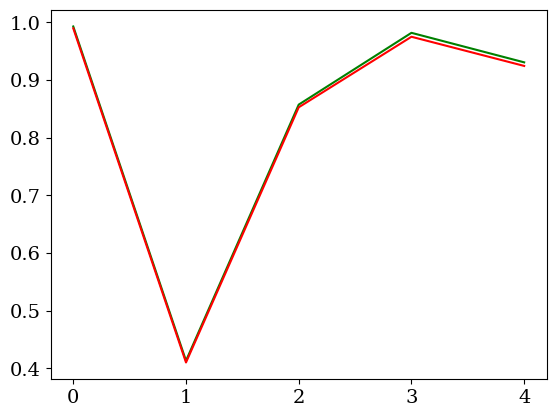

In [8]:
plt.plot(data, color="green")
plt.plot(pred, color="red")

# SuperMAG data

In [9]:
# start date year-month-day-hour-min-sec
start=[2019,5,1,10,40,10] 

In [10]:
# read in data
(status,stations) = SuperMAGGetInventory("opaliss", start, 3600)
# number of stations
N = len(stations)
print("number of stations = ", N)

number of stations =  199


In [11]:
# intialize data
data_Bn = np.zeros(N)
geo_lat = np.zeros(N)
geo_lon = np.zeros(N)

In [12]:
# read in data for 1hr in advance from start date at station "res"
# note: this is very slow.. not sure if there are faster ways to go about this
for ii in range(N):
    (status, sm_data) = SuperMAGGetData("opaliss", start, 3600,'geo', stations[ii])
    data_Bn[ii] = sm_data.N[0]["geo"]
    geo_lat[ii] = sm_data.glat[0] + 90
    geo_lon[ii] = sm_data.glon[0]

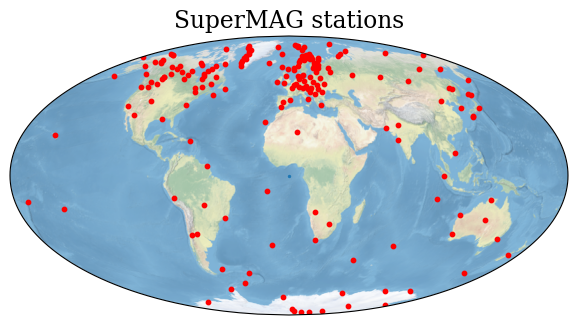

In [13]:
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mollweide())

ax.stock_img()
plt.scatter(geo_lon, geo_lat - 90, color="red", s=10, transform=ccrs.PlateCarree())

_ = plt.title("SuperMAG stations")
ax.scatter(0, 0, s=2)
ax.set_xlabel("longitude [deg]")
ax.set_ylabel("latitude [deg]")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig("figures/supermag_stations_locations.png", bbox_inches='tight', dpi=600)

## Spherical Harmonics Regression 

In [65]:
# order of spherical harmonic interpolator 
ell = 12
# ridge regression regularization 
lambda_ = 0.1

In [66]:
Y = get_spherical_harmonic_basis_matrix(latitude=geo_lat*np.pi/180, longitude=geo_lon*np.pi/180, ell=ell)

In [67]:
pred = construct_global_view(coeff=ridge_regression(basis_matrix=Y, data=data_Bn, lambda_=lambda_), 
                             longitude=geo_lon*np.pi/180, latitude=geo_lat*np.pi/180)

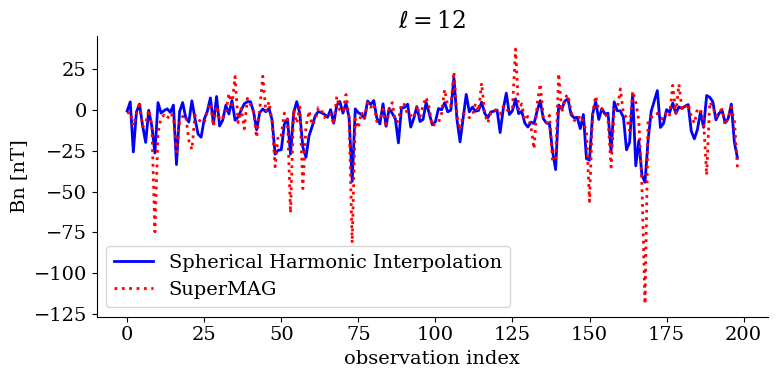

In [68]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pred, label="Spherical Harmonic Interpolation", linewidth=2, color="blue")
ax.plot(data_Bn, ls=":", label="SuperMAG", linewidth=2, color="red")
ax.set_xlabel("observation index")
ax.set_ylabel("Bn [nT]")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_title("$\ell = $" + str(ell))
_ = plt.tight_layout()
_ = plt.legend()

In [69]:
N_interp = 600
THETA, PHI = np.meshgrid(np.linspace(0, 180, N_interp, endpoint=False), 
                         np.linspace(0, 360, N_interp, endpoint=False))

In [70]:
pred = construct_global_view(coeff=ridge_regression(basis_matrix=Y, data=data_Bn, lambda_=lambda_), 
                             longitude=np.ndarray.flatten(PHI)*np.pi/180, 
                             latitude=np.ndarray.flatten(THETA)*np.pi/180)

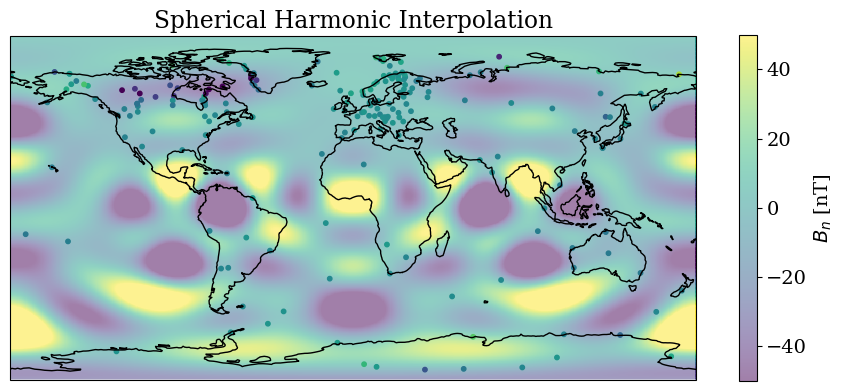

In [71]:
fig = plt.figure(figsize=(9, 4))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

ax.coastlines()
pos = ax.pcolormesh(PHI, THETA-90, np.reshape(pred, (N_interp, N_interp), order="C"), vmin=-50,
                    vmax=50, alpha=0.5, transform=ccrs.PlateCarree())
plt.scatter(geo_lon, geo_lat-90, c=data_Bn, s=10, cmap='viridis', vmin=-50, vmax=50, transform=ccrs.PlateCarree())
cbar = fig.colorbar(pos)
cbar.ax.set_ylabel("$B_{n}$ [nT]", rotation=90)

ax.set_title("Spherical Harmonic Interpolation")
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xlabel("longitude [deg]")
ax.set_ylabel("latitude [deg]")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()

plt.savefig("figures/supermag_stations_interpolation.png", bbox_inches='tight', dpi=600)

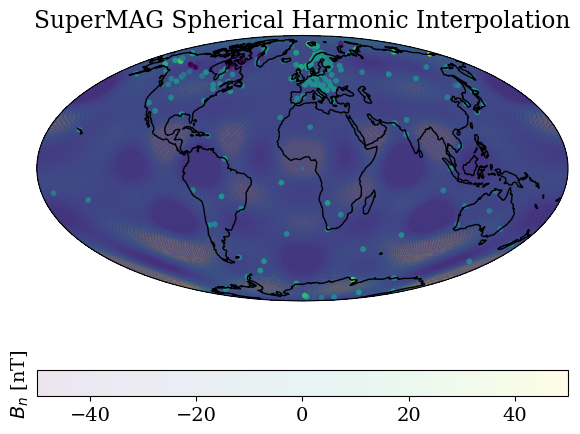

In [72]:
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Mollweide())

ax.coastlines()
pos = ax.pcolormesh(PHI, THETA-90, np.reshape(pred, (N_interp, N_interp), order="C"), vmin=-50,
                    vmax=50, alpha=0.1, transform=ccrs.PlateCarree())
plt.scatter(geo_lon, geo_lat-90, c=data_Bn, s=10, cmap='viridis', vmin=-50, vmax=50, transform=ccrs.PlateCarree())

cbar = fig.colorbar(pos, orientation="horizontal")
cbar.ax.set_ylabel("$B_{n}$ [nT]", rotation=90)


_ = plt.title("SuperMAG Spherical Harmonic Interpolation")
ax.scatter(0, 0, s=2)
ax.set_xlabel("longitude [deg]")
ax.set_ylabel("latitude [deg]")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.tight_layout()
plt.savefig("figures/supermag_stations_locations.png", bbox_inches='tight', dpi=600)